In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


# Problem 1

In [2]:
# Earth orbital elements
q_e = 9.78969676e-01      # au
e_e = 1.83889630e-02
i_e = 7.55697209e-05      # rad
omega_e = 5.34322623      # rad
Omega_e = 2.63906227      # rad
M0_e = 1.88972281         # rad


# FI2026 orbital elements
q_a = 0.74161536          # au
e_a = 0.19293483
i_a = 0.05877868          # rad
omega_a = 2.22509624      # rad
Omega_a = 3.55784498      # rad
M0_a = 3.64624167         # rad


def q_to_a(q, e):
    return q / (1 - e)


a_e = q_to_a(q_e, e_e) * 1.496e8
a_a = q_to_a(q_a, e_a) * 1.496e8


print(a_e)
print(a_a)

149197449.91579592
137468028.58064115


In [3]:
def kmToAU(km):
    return km / 1.496e+8


def AUtoKm(vec):
    AU_KM = 1.496e8
    return np.array(vec) * AU_KM


def R3_Omega(Omega):
    """
    Rotation about Z-axis by RAAN
    """
    return np.array([
        [ np.cos(Omega), -np.sin(Omega), 0.0],
        [ np.sin(Omega),  np.cos(Omega), 0.0],
        [ 0.0,            0.0,           1.0]
    ])


def R1_i(i):
    """
    Rotation about X-axis by inclination
    """
    return np.array([
        [1.0, 0.0,          0.0],
        [0.0, np.cos(i), -np.sin(i)],
        [0.0, np.sin(i),  np.cos(i)]
    ])


def R3_omega(omega):
    """
    Rotation about Z-axis by argument of periapsis
    """
    return np.array([
        [ np.cos(omega), -np.sin(omega), 0.0],
        [ np.sin(omega),  np.cos(omega), 0.0],
        [ 0.0,            0.0,           1.0]
    ])

In [4]:
def r_vec(a, e, f):
    r = a * (1 - e**2) / (1 + e * np.cos(f))
    r_vec = np.array([r * np.cos(f), r * np.sin(f), 0])
    return r_vec


def r_inertial(Omega, i, omega, a, e, f):
    R_Omega = R3_Omega(Omega)
    R_i = R1_i(i)
    R_omega = R3_omega(omega)

    vector = r_vec(a, e, f)
    return R_Omega @ R_i @ R_omega @ vector


def eccentric_anomaly(M, e, tol=1e-10):
    E = M  # initial guess
    
    while True:
        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        E_new = E - f/fp
        
        if abs(E_new - E) < tol:
            break
            
        E = E_new
        
    return E_new


def true_anomaly(E, e):
    return 2*np.arctan2(
        np.sqrt(1+e)*np.sin(E/2),
        np.sqrt(1-e)*np.cos(E/2)
    )


def mean_to_true_anomaly(M, e):
    E = eccentric_anomaly(M, e)
    f = true_anomaly(E, e)
    return f

In [5]:
f_e = mean_to_true_anomaly(M0_e, e_e)
f_a = mean_to_true_anomaly(M0_a, e_a)


r_e_initial = r_inertial(Omega_e, i_e, omega_e, a_e, e_e, f_e)
r_a_initial = r_inertial(Omega_a, i_a, omega_a, a_a, e_a, f_a)

print(r_e_initial)
print(r_a_initial)

test = r_a_initial - r_e_initial
print(np.linalg.norm(test))

[-1.33008489e+08 -6.95671488e+07  9.44841805e+03]
[-1.59781062e+08  2.38415610e+07 -5.08497748e+06]
97303190.50033014


In [8]:
def v_vec(a, e, f, mu):
    factor = np.sqrt(mu/(a*(1 - e**2)))
    
    return factor * np.array([
        -np.sin(f),
        e + np.cos(f),
        0
    ])


def v_inertial(Omega, i, omega, a, e, f, mu):

    R_Omega = R3_Omega(Omega)
    R_i = R1_i(i)
    R_omega = R3_omega(omega)

    vector = v_vec(a, e, f, mu)

    return R_Omega @ R_i @ R_omega @ vector


mu_sun = 1.32712440018e11


vel_e_initial = v_inertial(
    Omega_e, i_e, omega_e,
    a_e, e_e, f_e, mu_sun
)

vel_a_initial = v_inertial(
    Omega_a, i_a, omega_a,
    a_a, e_a, f_a, mu_sun
)

print(vel_e_initial)
print(vel_a_initial)

[ 1.32809362e+01 -2.65027443e+01  1.27179526e-03]
[ -1.78346974 -25.91832608   1.35253055]


In [9]:
def rk4_step(x_dot, t, x, dt):
    k1 = dt * x_dot(t, x)
    k2 = dt * x_dot(t + 0.5*dt, x + 0.5*k1)
    k3 = dt * x_dot(t + 0.5*dt, x + 0.5*k2)
    k4 = dt * x_dot(t + dt, x + k3)

    return x + (k1 + 2*k2 + 2*k3 + k4) / 6

mu_sun = 1.32712440018e11  # km^3/s^2


In [10]:
def x_dot(t, x):
    r = x[0:3]
    v = x[3:6]

    r_mag = np.linalg.norm(r)

    a = -mu_sun * r / r_mag**3

    xdot = np.zeros(6)
    xdot[0:3] = v        # dr/dt = v
    xdot[3:6] = a        # dv/dt = a

    return xdot


In [12]:
from tqdm import tqdm
import numpy as np

xE0 = np.concatenate((r_e_initial, vel_e_initial))
xA0 = np.concatenate((r_a_initial, vel_a_initial))

R_EARTH = 6378

dt = 86400   # coarse step (1 day)
t = 0

xE = xE0.copy()
xA = xA0.copy()

rE_vel_list = []
rA_vel_list = []

rE_pos_list = []
rA_pos_list = []

pbar = tqdm(unit="days")

while True:

    xE_next = rk4_step(x_dot, t, xE, dt)
    xA_next = rk4_step(x_dot, t, xA, dt)

    rE = xE_next[0:3]
    rA = xA_next[0:3]

    rE_pos_list.append(rE)
    rA_pos_list.append(rA)

    rE_vel_list.append(xE_next[3:6])
    rA_vel_list.append(xA_next[3:6])

    d = np.linalg.norm(rA - rE)

    if d <= R_EARTH:
        print("Impact window found between")
        print("Day:", t/86400, "and", (t+dt)/86400)
        break

    xE = xE_next
    xA = xA_next
    t += dt
    pbar.update(1)

pbar.close()


# rewind to start of window
dt_refine = 60   # 1 minute timestep

xE_ref = xE.copy()
xA_ref = xA.copy()
t_ref = t

while True:

    xE_ref = rk4_step(x_dot, t_ref, xE_ref, dt_refine)
    xA_ref = rk4_step(x_dot, t_ref, xA_ref, dt_refine)

    rE = xE_ref[0:3]
    rA = xA_ref[0:3]

    d = np.linalg.norm(rA - rE)

    if d <= R_EARTH:
        print("\nImpact detected!")
        print("Time to impact (seconds):", t_ref)
        print("Time to impact (days):", t_ref/86400)
        break

    t_ref += dt_refine

0days [00:00, ?days/s]

359days [00:00, 2659.00days/s]


Impact window found between
Day: 359.0 and 360.0

Impact detected!
Time to impact (seconds): 31103580
Time to impact (days): 359.9951388888889


# Problem 2

In [13]:
r_rel = rA_pos_list[-4] - rE_pos_list[-4]
v_rel = rA_vel_list[-4] - rE_vel_list[-4]
print(r_rel)
np.linalg.norm(r_rel)


[-1092402.32107016  -986843.84190138  -426091.76964028]


np.float64(1532565.755696421)

In [14]:
v_inf = np.linalg.norm(v_rel)
print(v_inf)
S_hat = v_rel / v_inf
h = np.cross(r_rel, v_rel)

S_hat

5.9049996502035595


array([0.71347392, 0.6434171 , 0.2774336 ])

In [15]:
v_inf = np.linalg.norm(v_rel)
B = np.cross(S_hat, h) / v_inf
print(B)

[1042.78842342 -765.34567422 -906.76054435]


In [16]:
V_hat = rE_vel_list[-3] / np.linalg.norm(rE_vel_list[-3])

T_hat = np.cross(V_hat, S_hat)
T_hat = T_hat / np.linalg.norm(T_hat)

R_hat = np.cross(S_hat, T_hat)

In [17]:
xi = np.dot(B, T_hat)
zeta = np.dot(B, R_hat)

print(xi)
print(zeta)

-1073.5257406722137
1158.8437625405804


In [18]:
mu_E = 398600
R_E = 6378

b_max = R_E * np.sqrt(1 + (2*mu_E)/(R_E*v_inf**2))

print(b_max)

13656.397449219645


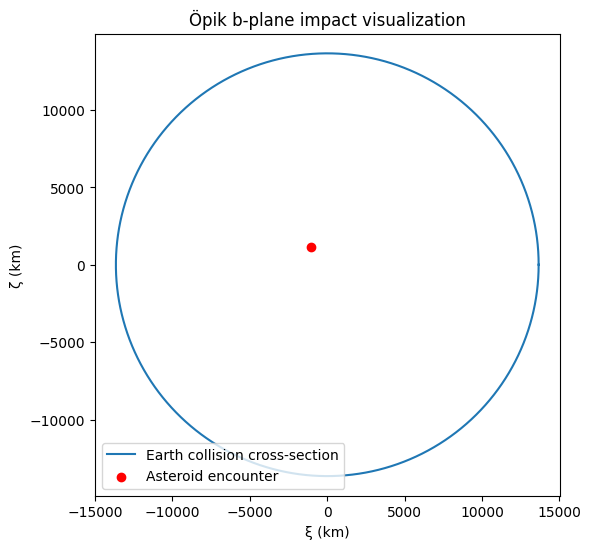

In [19]:
theta = np.linspace(0,2*np.pi,200)

circle_x = b_max*np.cos(theta)
circle_y = b_max*np.sin(theta)

plt.figure(figsize=(6,6))
plt.plot(circle_x, circle_y, label="Earth collision cross-section")
plt.scatter(xi, zeta, color='red', label="Asteroid encounter")

plt.xlabel("ξ (km)")
plt.ylabel("ζ (km)")
plt.axis("equal")

plt.legend(loc='lower left')

plt.title("Öpik b-plane impact visualization")
plt.show()

# Problem 3

In [20]:
import numpy as np

# -------------------------------------------------
# GAUSS PLANETARY EQUATIONS
# -------------------------------------------------

def gauss_rates(elements, accel):

    a, e, i, Omega, omega, M = elements
    a_r, a_theta, a_h = accel

    v = mean_to_true_anomaly_fast(M, e)

    p = a*(1 - e**2)

    h = np.sqrt(mu_sun * p)

    r = p/(1 + e*np.cos(v))

    theta = omega + v

    n = np.sqrt(mu_sun/a**3)

    a_dot = (2*a**2/h)*(e*np.sin(v)*a_r + (p/r)*a_theta)

    e_dot = (1/h)*(p*np.sin(v)*a_r + ((p+r)*np.cos(v)+r*e)*a_theta)

    i_dot = (r*np.cos(theta)/h)*a_h

    Omega_dot = (r*np.sin(theta)/(h*np.sin(i)))*a_h

    omega_dot = (1/(h*e))*(-p*np.cos(v)*a_r + (p+r)*np.sin(v)*a_theta) \
                - (r*np.sin(theta)*np.cos(i)/(h*np.sin(i)))*a_h

    M_dot = n + (1/(a*h*e))*((p*np.cos(v)-2*r*e)*a_r - (p+r)*np.sin(v)*a_theta)

    return np.array([a_dot,e_dot,i_dot,Omega_dot,omega_dot,M_dot])


# -------------------------------------------------
# RK4 STEP
# -------------------------------------------------

def rk4_elements(elements, accel, dt):

    k1 = dt * gauss_rates(elements, accel)

    k2 = dt * gauss_rates(elements + 0.5*k1, accel)

    k3 = dt * gauss_rates(elements + 0.5*k2, accel)

    k4 = dt * gauss_rates(elements + k3, accel)

    return elements + (k1 + 2*k2 + 2*k3 + k4)/6


# -------------------------------------------------
# INTEGRATOR
# -------------------------------------------------

def integrate_gauss(elements0, accel, dt, t_final):

    elements = elements0.copy()

    t = 0

    while t < t_final:

        elements = rk4_elements(elements, accel, dt)

        # safety clamps
        elements[1] = np.clip(elements[1], 1e-8, 0.999)
        elements[5] = np.mod(elements[5], 2*np.pi)

        t += dt

    return elements

def rk4_integrate(x_dot, t_span, y0, dt):
    # counter = 0 #remove this later
    t0, tf = t_span
    t_vals = np.arange(t0, tf, dt)
    num_steps = len(t_vals)
    y_vals = np.zeros((num_steps, len(y0)))
    y_vals[0, :] = y0
    for i in tqdm(range(num_steps - 1)):
        t = t_vals[i]
        y = y_vals[i, :]
        k1 = dt * x_dot(t, y)
        k2 = dt * x_dot(t + 0.5 * dt, np.add(y, 0.5 * k1))
        k3 = dt * x_dot(t + 0.5 * dt, np.add(y, 0.5 * k2))
        k4 = dt * x_dot(t + dt, np.add(y, k3))
        y_vals[i + 1, :] = np.add(y, ((k1 + 2 * k2 + 2 * k3 + k4) / 6))
    return t_vals, y_vals

mu = 398600

def eccentric_anomaly_fast(M, e, iterations=10):

    # wrap mean anomaly
    M = np.mod(M, 2*np.pi)

    # initial guess
    E = M

    for _ in range(iterations):
        E = E - (E - e*np.sin(E) - M) / (1 - e*np.cos(E))

    return E


def true_anomaly_fast(E, e):

    return 2*np.arctan2(
        np.sqrt(1 + e) * np.sin(E/2),
        np.sqrt(1 - e) * np.cos(E/2)
    )


def mean_to_true_anomaly_fast(M, e):

    E = eccentric_anomaly_fast(M, e)

    v = true_anomaly_fast(E, e)

    return v

In [21]:
# ---------------------------------------
# FI2026 orbital elements (Problem 3)
# ---------------------------------------

q_a_problem3 = 0.74161536      # AU
e_a_problem3 = 0.19293483
i_a_problem3 = 0.05877868       # rad
omega_a_problem3 = 2.22509624   # rad
Omega_a_problem3 = 3.55784498   # rad
M0_a_problem3 = 3.64624167       # rad


# ---------------------------------------
# Earth elements (Problem 3 copies)
# ---------------------------------------

q_e_problem3 = q_e
e_e_problem3 = e_e
i_e_problem3 = i_e
omega_e_problem3 = omega_e
Omega_e_problem3 = Omega_e
M0_e_problem3 = M0_e


# ---------------------------------------
# Convert q → a
# ---------------------------------------

def q_to_a(q, e):
    return q / (1 - e)


a_e_problem3 = q_to_a(q_e_problem3, e_e_problem3) * 1.496e8
a_a_problem3 = q_to_a(q_a_problem3, e_a_problem3) * 1.496e8


print("Earth a:", a_e_problem3)
print("FI2026 a:", a_a_problem3)


# ---------------------------------------
# Initial element vector for Gauss
# ---------------------------------------

elements_problem3 = np.array([
    a_a_problem3,
    e_a_problem3,
    i_a_problem3,
    Omega_a_problem3,
    omega_a_problem3,
    M0_a_problem3
])

Earth a: 149197449.91579592
FI2026 a: 137468028.58064115


In [22]:
t_thrust_problem3 = 0
dt_thrust_problem3 = 10
dt_propagation_problem3 = 86400

accel_problem3 = np.array([0.0, 1e-5, 0.0])

step_problem3 = 0

encounter_time_problem3 = 359.9951388888889 * 86400

print("Target B-plane threshold:", 4*R_EARTH)

r_e_problem3 = r_e_initial
v_e_problem3 = vel_e_initial

while True:

    # ------------------------------------------------
    # 1 BUILD ASTEROID STATE FROM CURRENT ELEMENTS
    # ------------------------------------------------

    a_problem3, e_problem3, i_problem3, Omega_problem3, omega_problem3, M_problem3 = elements_problem3

    f_problem3 = mean_to_true_anomaly(M_problem3, e_problem3)

    r_a_problem3 = r_inertial(
        Omega_problem3,
        i_problem3,
        omega_problem3,
        a_problem3,
        e_problem3,
        f_problem3
    )

    v_a_problem3 = v_inertial(
        Omega_problem3,
        i_problem3,
        omega_problem3,
        a_problem3,
        e_problem3,
        f_problem3,
        mu_sun
    )

    xA0_problem3 = np.concatenate((r_a_problem3, v_a_problem3))

    # ------------------------------------------------
    # 2 PROPAGATE ASTEROID TO ENCOUNTER
    # ------------------------------------------------

    tA_problem3, yA_problem3 = rk4_integrate(
        x_dot,
        (0, encounter_time_problem3),
        xA0_problem3,
        dt_propagation_problem3
    )

    rA_problem3 = yA_problem3[:,0:3]
    vA_problem3 = yA_problem3[:,3:6]

    # ------------------------------------------------
    # 3 PROPAGATE EARTH TO ENCOUNTER
    # ------------------------------------------------

    xE0_problem3 = np.concatenate((r_e_problem3, v_e_problem3))

    tE_problem3, yE_problem3 = rk4_integrate(
        x_dot,
        (0, encounter_time_problem3),
        xE0_problem3,
        dt_propagation_problem3
    )

    rE_problem3 = yE_problem3[:,0:3]
    vE_problem3 = yE_problem3[:,3:6]

    # ------------------------------------------------
    # 4 RELATIVE STATE
    # ------------------------------------------------

    r_rel_problem3 = rA_problem3[-2] - rE_problem3[-2]
    v_rel_problem3 = vA_problem3[-2] - vE_problem3[-2]

    # ------------------------------------------------
    # 5 B-PLANE
    # ------------------------------------------------

    v_inf_problem3 = np.linalg.norm(v_rel_problem3)

    S_hat_problem3 = v_rel_problem3 / v_inf_problem3

    h_problem3 = np.cross(r_rel_problem3, v_rel_problem3)

    B_problem3 = np.cross(S_hat_problem3, h_problem3) / v_inf_problem3

    # ------------------------------------------------
    # 6 B-PLANE AXES
    # ------------------------------------------------

    V_hat_problem3 = vE_problem3[-3] / np.linalg.norm(vE_problem3[-3])

    T_hat_problem3 = np.cross(V_hat_problem3, S_hat_problem3)
    T_hat_problem3 = T_hat_problem3 / np.linalg.norm(T_hat_problem3)

    R_hat_problem3 = np.cross(S_hat_problem3, T_hat_problem3)

    # ------------------------------------------------
    # 7 B-PLANE COORDINATES
    # ------------------------------------------------

    xi_problem3 = np.dot(B_problem3, T_hat_problem3)
    zeta_problem3 = np.dot(B_problem3, R_hat_problem3)

    B_mag_problem3 = np.sqrt(xi_problem3**2 + zeta_problem3**2)

    print("xi:", xi_problem3)
    print("zeta:", zeta_problem3)

    print(
        f"Thrust days: {t_thrust_problem3/86400:.2f} | "
        f"B = {B_mag_problem3:.2f} km"
    )

    # ------------------------------------------------
    # 8 DEFLECTION CHECK
    # ------------------------------------------------

    if B_mag_problem3 >= 4 * R_EARTH:

        print("\nDeflection achieved")
        print("Thrust time (days):", t_thrust_problem3/86400)
        print("Thrust time (seconds):", t_thrust_problem3)

        deltaV_problem3 = np.linalg.norm(accel_problem3) * t_thrust_problem3
        print("Delta V:", deltaV_problem3 * 1000, "m/s")

        break

    # ------------------------------------------------
    # 9 APPLY GAUSS THRUST UPDATE
    # ------------------------------------------------

    elements_problem3 = integrate_gauss(
        elements_problem3,
        accel_problem3,
        dt_thrust_problem3,
        dt_thrust_problem3
    )

    # ------------------------------------------------
    # 10 ADVANCE MEAN ANOMALY (ASTEROID MOVES)
    # ------------------------------------------------

    a_problem3 = elements_problem3[0]
    n_problem3 = np.sqrt(mu_sun / a_problem3**3)

    elements_problem3[5] += n_problem3 * dt_thrust_problem3

    # ------------------------------------------------

    t_thrust_problem3 += dt_thrust_problem3
    step_problem3 += 1

Target B-plane threshold: 25512


100%|██████████| 359/359 [00:00<00:00, 5844.62it/s]


xi: -323.67364623637513
zeta: 335.8712960423926
Thrust days: 0.00 | B = 466.45 km


100%|██████████| 359/359 [00:00<00:00, 13510.95it/s]


xi: -143.26400886467957
zeta: -6743.790600544411
Thrust days: 0.00 | B = 6745.31 km


...

xi: 37.35318633856423
zeta: -13823.454287261684
Thrust days: 0.00 | B = 13823.50 km


100%|██████████| 359/359 [00:00<00:00, 14165.55it/s]


xi: 218.17811035855016
zeta: -20903.119448592668
Thrust days: 0.00 | B = 20904.26 km


100%|██████████| 359/359 [00:00<00:00, 17377.84it/s]

xi: 399.2109332786281
zeta: -27982.785768721176
Thrust days: 0.00 | B = 27985.63 km

Deflection achieved
Thrust time (days): 0.000462962962962963
Thrust time (seconds): 40
Delta V: 0.4 m/s


# Problem 4

In [23]:
# ---------------------------------------
# REBUILD INITIAL ASTEROID ORBIT
# ---------------------------------------

a_a = q_to_a(q_a, e_a) * 1.496e8

elements_kinetic = np.array([
    a_a,
    e_a,
    i_a,
    Omega_a,
    omega_a,
    M0_a
])

print("Initial elements used:", elements_kinetic)

# ---------------------------------------
# KINETIC IMPACT PARAMETERS
# ---------------------------------------

deltaV = 0.0
deltaV_step = 1e-5   # km/s increment

dt_propagation = 86400

encounter_time = 359.9951388888889 * 86400

print("Target B-plane threshold:", 4 * R_EARTH)

# ---------------------------------------
# PROPAGATE EARTH ONCE
# ---------------------------------------

xE0 = np.concatenate((r_e_initial, vel_e_initial))

tE, yE = rk4_integrate(
    x_dot,
    (0, encounter_time),
    xE0,
    dt_propagation
)

rE = yE[:,0:3]
vE = yE[:,3:6]

# ---------------------------------------
# DEFLECTION LOOP
# ---------------------------------------

while True:

    a, e, i, Omega, omega, M = elements_kinetic

    f_true = mean_to_true_anomaly(M, e)

    r_ast = r_inertial(
        Omega,
        i,
        omega,
        a,
        e,
        f_true
    )

    v_ast = v_inertial(
        Omega,
        i,
        omega,
        a,
        e,
        f_true,
        mu_sun
    )

    # ---------------------------------------
    # APPLY KINETIC IMPACT ΔV
    # ---------------------------------------

    v_hat = v_ast / np.linalg.norm(v_ast)

    v_ast_deflected = v_ast + deltaV * v_hat

    xA0 = np.concatenate((r_ast, v_ast_deflected))

    # ---------------------------------------
    # PROPAGATE ASTEROID
    # ---------------------------------------

    tA, yA = rk4_integrate(
        x_dot,
        (0, encounter_time),
        xA0,
        dt_propagation
    )

    rA = yA[:,0:3]
    vA = yA[:,3:6]

    # ---------------------------------------
    # RELATIVE STATE AT ENCOUNTER
    # ---------------------------------------

    r_rel = rA[-1] - rE[-1]
    v_rel = vA[-1] - vE[-1]

    v_inf = np.linalg.norm(v_rel)

    S_hat = v_rel / v_inf

    h = np.cross(r_rel, v_rel)

    B_vec = np.cross(S_hat, h) / v_inf

    # ---------------------------------------
    # B-PLANE AXES
    # ---------------------------------------

    V_hat = vE[-1] / np.linalg.norm(vE[-1])

    T_hat = np.cross(V_hat, S_hat)
    T_hat /= np.linalg.norm(T_hat)

    R_hat = np.cross(S_hat, T_hat)

    # ---------------------------------------
    # B-PLANE COORDINATES
    # ---------------------------------------

    xi_kinetic = np.dot(B_vec, T_hat)
    zeta_kinetic = np.dot(B_vec, R_hat)

    B_mag = np.sqrt(xi_kinetic**2 + zeta_kinetic**2)

    print("ΔV:", deltaV*1000, "m/s")
    print("B:", B_mag, "km")

    # ---------------------------------------
    # DEFLECTION CHECK
    # ---------------------------------------

    if B_mag >= 4 * R_EARTH:

        print("\nDeflection achieved")
        print("Required ΔV:", deltaV*1000, "m/s")

        break

    # ---------------------------------------
    # INCREASE IMPACT ENERGY
    # ---------------------------------------

    deltaV += deltaV_step

Initial elements used: [1.37468029e+08 1.92934830e-01 5.87786800e-02 3.55784498e+00
 2.22509624e+00 3.64624167e+00]
Target B-plane threshold: 25512


100%|██████████| 359/359 [00:00<00:00, 9227.85it/s]


ΔV: 0.0 m/s
B: 60.65350766476804 km


100%|██████████| 359/359 [00:00<00:00, 6681.61it/s]


ΔV: 0.01 m/s
B: 566.7057924391431 km


...

ΔV: 0.4000000000000004 m/s
B: 24404.357356735334 km


100%|██████████| 359/359 [00:00<00:00, 8353.33it/s]


ΔV: 0.4100000000000004 m/s
B: 25015.60893408301 km


100%|██████████| 359/359 [00:00<00:00, 9943.90it/s]

ΔV: 0.42000000000000043 m/s
B: 25626.860335069752 km

Deflection achieved
Required ΔV: 0.42000000000000043 m/s


# Problem 5

In [24]:
q_FI2026 = 0.74161536         # au
e_FI2026 = 0.19293483
i_FI2026 = 0.05877868         # rad
omega_FI2026 = 2.22509624     # rad
Omega_FI2026 = 3.55784498     # rad
M_FI2026 = 3.64624167         # rad

def q_to_a(q, e):
    return q / (1 - e)

a_Earth = q_to_a(q_e, e_e) * 1.496e8
a_FI2026 = q_to_a(q_FI2026, e_FI2026) * 1.496e8


In [25]:
# ---------------------------------------
# REBUILD INITIAL ASTEROID ORBIT
# ---------------------------------------

a_a = q_to_a(q_a, e_a) * 1.496e8

elements_radial = np.array([
    a_a,
    e_a,
    i_a,
    Omega_a,
    omega_a,
    M0_a
])

print("Initial elements used:", elements_radial)

# ---------------------------------------
# THRUST SETTINGS
# ---------------------------------------

t_thrust_radial = 0
dt_thrust_radial = 10
dt_propagation_radial = 86400

accel_radial = np.array([1e-5, 0.0, 0.0])

encounter_time_radial = 359.9951388888889 * 86400

print("Target B-plane threshold:", 4 * R_EARTH)

# ---------------------------------------
# PROPAGATE EARTH ONCE
# ---------------------------------------

xE0 = np.concatenate((r_e_initial, vel_e_initial))

tE, yE = rk4_integrate(
    x_dot,
    (0, encounter_time_radial),
    xE0,
    dt_propagation_radial
)

rE = yE[:,0:3]
vE = yE[:,3:6]

# ---------------------------------------
# DEFLECTION LOOP
# ---------------------------------------

while True:

    a, e, i, Omega, omega, M = elements_radial

    f_true = mean_to_true_anomaly(M, e)

    r_ast = r_inertial(
        Omega,
        i,
        omega,
        a,
        e,
        f_true
    )

    v_ast = v_inertial(
        Omega,
        i,
        omega,
        a,
        e,
        f_true,
        mu_sun
    )

    xA0 = np.concatenate((r_ast, v_ast))

    # propagate asteroid
    tA, yA = rk4_integrate(
        x_dot,
        (0, encounter_time_radial),
        xA0,
        dt_propagation_radial
    )

    rA = yA[:,0:3]
    vA = yA[:,3:6]

    # relative state at encounter
    r_rel = rA[-1] - rE[-1]
    v_rel = vA[-1] - vE[-1]

    v_inf = np.linalg.norm(v_rel)

    S_hat = v_rel / v_inf

    h = np.cross(r_rel, v_rel)

    B_vec = np.cross(S_hat, h) / v_inf

    # B-plane axes
    V_hat = vE[-1] / np.linalg.norm(vE[-1])

    T_hat = np.cross(V_hat, S_hat)
    T_hat /= np.linalg.norm(T_hat)

    R_hat = np.cross(S_hat, T_hat)

    # coordinates
    xi_radial = np.dot(B_vec, T_hat)
    zeta_radial = np.dot(B_vec, R_hat)

    B_mag = np.sqrt(xi_radial**2 + zeta_radial**2)

    print("xi:", xi_radial)
    print("zeta:", zeta_radial)
    print(f"Thrust days: {t_thrust_radial/86400:.2f} | B = {B_mag:.2f} km")

    if B_mag >= 4 * R_EARTH:

        print("\nDeflection achieved")
        print("Thrust time (days):", t_thrust_radial/86400)
        print("Thrust time (seconds):", t_thrust_radial)

        deltaV = np.linalg.norm(accel_radial) * t_thrust_radial
        print("Delta V:", deltaV * 1000, "m/s")

        break

    # thrust update
    elements_radial = integrate_gauss(
        elements_radial,
        accel_radial,
        dt_thrust_radial,
        dt_thrust_radial
    )

    # advance mean anomaly
    a = elements_radial[0]
    n = np.sqrt(mu_sun / a**3)

    elements_radial[5] += n * dt_thrust_radial

    t_thrust_radial += dt_thrust_radial

Initial elements used: [1.37468029e+08 1.92934830e-01 5.87786800e-02 3.55784498e+00
 2.22509624e+00 3.64624167e+00]
Target B-plane threshold: 25512


  0%|          | 0/359 [00:00<?, ?it/s]

100%|██████████| 359/359 [00:00<00:00, 13006.66it/s]


xi: -40.29188771253856
zeta: 45.336649375535686
Thrust days: 0.00 | B = 60.65 km


100%|██████████| 359/359 [00:00<00:00, 7658.71it/s]


...

xi: 349.8940411311794
zeta: 21825.772466544964
Thrust days: 0.00 | B = 21828.58 km


100%|██████████| 359/359 [00:00<00:00, 17797.68it/s]


xi: 414.96690759939565
zeta: 25456.080858474947
Thrust days: 0.00 | B = 25459.46 km


100%|██████████| 359/359 [00:00<00:00, 17250.23it/s]

xi: 480.05172878219855
zeta: 29086.456512909746
Thrust days: 0.00 | B = 29090.42 km

Deflection achieved
Thrust time (days): 0.000925925925925926
Thrust time (seconds): 80
Delta V: 0.8 m/s


In [26]:
# ---------------------------------------
# REBUILD INITIAL ASTEROID ORBIT
# ---------------------------------------

a_a = q_to_a(q_a, e_a) * 1.496e8

elements_normal = np.array([
    a_a,
    e_a,
    i_a,
    Omega_a,
    omega_a,
    M0_a
])

print("Initial elements used:", elements_normal)

# ---------------------------------------
# THRUST PARAMETERS
# ---------------------------------------

t_thrust_normal = 0
dt_thrust_normal = 10
dt_propagation_normal = 86400

accel_normal = np.array([0.0, 0.0, 1e-5])

step_normal = 0

encounter_time_normal = 359.9951388888889 * 86400

print("Target B-plane threshold:", 4 * R_EARTH)

r_e_normal = r_e_initial
v_e_normal = vel_e_initial


while True:

    # ------------------------------------------------
    # 1 BUILD ASTEROID STATE FROM CURRENT ELEMENTS
    # ------------------------------------------------

    a_normal, e_normal, i_normal, Omega_normal, omega_normal, M_normal = elements_normal

    f_normal = mean_to_true_anomaly(M_normal, e_normal)

    r_a_normal = r_inertial(
        Omega_normal,
        i_normal,
        omega_normal,
        a_normal,
        e_normal,
        f_normal
    )

    v_a_normal = v_inertial(
        Omega_normal,
        i_normal,
        omega_normal,
        a_normal,
        e_normal,
        f_normal,
        mu_sun
    )

    xA0_normal = np.concatenate((r_a_normal, v_a_normal))

    # ------------------------------------------------
    # 2 PROPAGATE ASTEROID TO ENCOUNTER
    # ------------------------------------------------

    tA_normal, yA_normal = rk4_integrate(
        x_dot,
        (0, encounter_time_normal),
        xA0_normal,
        dt_propagation_normal
    )

    rA_normal = yA_normal[:,0:3]
    vA_normal = yA_normal[:,3:6]

    # ------------------------------------------------
    # 3 PROPAGATE EARTH
    # ------------------------------------------------

    xE0_normal = np.concatenate((r_e_normal, v_e_normal))

    tE_normal, yE_normal = rk4_integrate(
        x_dot,
        (0, encounter_time_normal),
        xE0_normal,
        dt_propagation_normal
    )

    rE_normal = yE_normal[:,0:3]
    vE_normal = yE_normal[:,3:6]

    # ------------------------------------------------
    # 4 RELATIVE STATE
    # ------------------------------------------------

    r_rel_normal = rA_normal[-2] - rE_normal[-2]
    v_rel_normal = vA_normal[-2] - vE_normal[-2]

    # ------------------------------------------------
    # 5 B-PLANE
    # ------------------------------------------------

    v_inf_normal = np.linalg.norm(v_rel_normal)

    S_hat_normal = v_rel_normal / v_inf_normal

    h_normal = np.cross(r_rel_normal, v_rel_normal)

    B_normal = np.cross(S_hat_normal, h_normal) / v_inf_normal

    # ------------------------------------------------
    # 6 B-PLANE AXES
    # ------------------------------------------------

    V_hat_normal = vE_normal[-3] / np.linalg.norm(vE_normal[-3])

    T_hat_normal = np.cross(V_hat_normal, S_hat_normal)
    T_hat_normal /= np.linalg.norm(T_hat_normal)

    R_hat_normal = np.cross(S_hat_normal, T_hat_normal)

    # ------------------------------------------------
    # 7 B-PLANE COORDINATES
    # ------------------------------------------------

    xi_normal = np.dot(B_normal, T_hat_normal)
    zeta_normal = np.dot(B_normal, R_hat_normal)

    B_mag_normal = np.sqrt(xi_normal**2 + zeta_normal**2)

    print("xi:", xi_normal)
    print("zeta:", zeta_normal)

    print(
        f"Thrust days: {t_thrust_normal/86400:.2f} | "
        f"B = {B_mag_normal:.2f} km"
    )

    # ------------------------------------------------
    # 8 DEFLECTION CHECK
    # ------------------------------------------------

    if B_mag_normal >= 4 * R_EARTH:

        print("\nDeflection achieved")
        print("Thrust time (days):", t_thrust_normal/86400)
        print("Thrust time (seconds):", t_thrust_normal)

        deltaV_normal = np.linalg.norm(accel_normal) * t_thrust_normal
        print("Delta V:", deltaV_normal * 1000, "m/s")

        break

    # ------------------------------------------------
    # 9 APPLY GAUSS THRUST UPDATE
    # ------------------------------------------------

    elements_normal = integrate_gauss(
        elements_normal,
        accel_normal,
        dt_thrust_normal,
        dt_thrust_normal
    )

    # ------------------------------------------------
    # 10 ADVANCE MEAN ANOMALY
    # ------------------------------------------------

    a_normal = elements_normal[0]
    n_normal = np.sqrt(mu_sun / a_normal**3)

    elements_normal[5] += n_normal * dt_thrust_normal

    # ------------------------------------------------

    t_thrust_normal += dt_thrust_normal
    step_normal += 1

Initial elements used: [1.37468029e+08 1.92934830e-01 5.87786800e-02 3.55784498e+00
 2.22509624e+00 3.64624167e+00]
Target B-plane threshold: 25512


100%|██████████| 359/359 [00:00<00:00, 8885.14it/s]


100%|██████████| 359/359 [00:00<00:00, 13328.81it/s]


xi: -323.67364623637513
zeta: 335.8712960423926
Thrust days: 0.00 | B = 466.45 km


100%|██████████| 359/359 [00:00<00:00, 15351.69it/s]


...

xi: 10581.338896667017
zeta: 22355.023142972303
Thrust days: 0.00 | B = 24732.81 km


100%|██████████| 359/359 [00:00<00:00, 13413.46it/s]


xi: 10868.251692745482
zeta: 22934.500517232555
Thrust days: 0.00 | B = 25379.33 km


100%|██████████| 359/359 [00:00<00:00, 11419.17it/s]

xi: 11155.16135179391
zeta: 23513.979219752393
Thrust days: 0.00 | B = 26025.85 km

Deflection achieved
Thrust time (days): 0.004629629629629629
Thrust time (seconds): 400
Delta V: 4.0 m/s


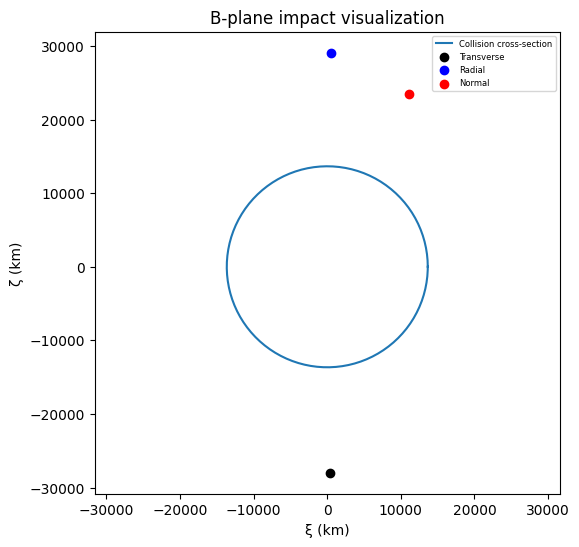

In [28]:
theta = np.linspace(0,2*np.pi,200)

circle_x = b_max*np.cos(theta)
circle_y = b_max*np.sin(theta)

plt.figure(figsize=(6,6))
plt.plot(circle_x, circle_y, label="Collision cross-section")
plt.scatter(xi_problem3, zeta_problem3, color='Black', label= "Transverse")
plt.scatter(xi_radial, zeta_radial, color='Blue', label="Radial")
plt.scatter(xi_normal, zeta_normal, color='red', label="Normal")


plt.xlabel("ξ (km)")
plt.ylabel("ζ (km)")
plt.axis("equal")

plt.legend(loc='upper right', fontsize = 6)

plt.title("B-plane impact visualization")
plt.show()

The Transverse direction is the most effective because it has the least delta V required to change the asteroid.

# Problem 6

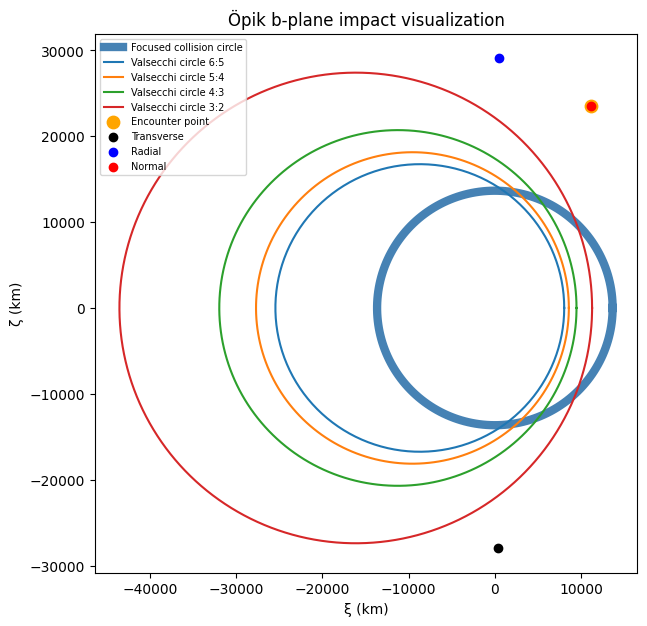

In [29]:
# ---------------------------------------------------------
# ENCOUNTER GEOMETRY
# ---------------------------------------------------------

vE = vel_e_initial
vA = vel_a_initial

theta_encounter = np.arccos(
    np.dot(vE, vA) /
    (np.linalg.norm(vE) * np.linalg.norm(vA))
)

v_inf = v_inf_normal


# ---------------------------------------------------------
# VALSECCHI CIRCLE FUNCTION
# ---------------------------------------------------------

def valsecchi_circle(p, q, v_inf, theta):

    mu_E = 398600.0     # km^3/s^2
    v_E  = 29.78        # km/s

    U = v_inf / v_E
    c = mu_E / v_inf**2

    a_res = (p/q)**(2/3)

    cos_theta0 = (1 - U**2 - 1/a_res)/(2*U)
    theta0 = np.arccos(cos_theta0)

    D = (c*np.sin(theta)) / (cos_theta0 - np.cos(theta))
    R = abs((c*np.sin(theta0)) / (cos_theta0 - np.cos(theta)))

    return D, R


# ---------------------------------------------------------
# RESONANCES (omit 7:6 to avoid huge circle)
# ---------------------------------------------------------

resonances = [
    (6,5),
    (5,4),
    (4,3),
    (3,2),
    (2,1)
]


# ---------------------------------------------------------
# CIRCLE PARAMETER
# ---------------------------------------------------------

phi = np.linspace(0, 2*np.pi, 400)


# ---------------------------------------------------------
# PLOT
# ---------------------------------------------------------

plt.figure(figsize=(7,7))


# ---------------------------------------------------------
# EARTH COLLISION CROSS SECTION
# ---------------------------------------------------------

theta_plot = np.linspace(0,2*np.pi,200)

circle_x = b_max*np.cos(theta_plot)
circle_y = b_max*np.sin(theta_plot)

plt.plot(
    circle_x,
    circle_y,
    linewidth=6,
    color="steelblue",
    label="Focused collision circle"
)


# ---------------------------------------------------------
# VALSECCHI RESONANCE CIRCLES
# ---------------------------------------------------------

for p,q in resonances:

    D, R = valsecchi_circle(p,q,v_inf,theta_encounter)

    # Skip circles that are absurdly large
    if R > 5*b_max:
        continue

    x = D + R*np.cos(phi)
    y = R*np.sin(phi)

    plt.plot(x,y,label=f"Valsecchi circle {p}:{q}")


# ---------------------------------------------------------
# ENCOUNTER POINT
# ---------------------------------------------------------

plt.scatter(
    xi_normal,
    zeta_normal,
    color="orange",
    s=80,
    label="Encounter point"
)


# ---------------------------------------------------------
# YOUR TRAJECTORIES
# ---------------------------------------------------------

plt.scatter(
    xi_problem3,
    zeta_problem3,
    color="black",
    label="Transverse"
)

plt.scatter(
    xi_radial,
    zeta_radial,
    color="blue",
    label="Radial"
)

plt.scatter(
    xi_normal,
    zeta_normal,
    color="red",
    label="Normal"
)


# ---------------------------------------------------------
# AXES / LABELS
# ---------------------------------------------------------

plt.xlabel("ξ (km)")
plt.ylabel("ζ (km)")

plt.axis("equal")

plt.legend(fontsize=7)

plt.title("Öpik b-plane impact visualization")

plt.show()